In [6]:
import yfinance as yf
import pandas as pd

print("Fetching live market data, please wait...")
btc_data = yf.download('BTC-USD', period='2y', interval='1d')

print("Data fetched successfully! First 5 rows:")
display(btc_data.head())

Fetching live market data, please wait...


[*********************100%***********************]  1 of 1 completed

Data fetched successfully! First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-04-20,64994.441406,65442.457031,63172.402344,63851.101562,23097485495
2024-04-21,64926.644531,65723.242188,64277.722656,64992.816406,20506644853
2024-04-22,66837.679688,67233.960938,64548.179688,64935.632812,28282686673
2024-04-23,66407.273438,67199.242188,65864.867188,66839.890625,24310975583
2024-04-24,64276.898438,67075.367188,63589.871094,66408.718750,30276655120


In [7]:
df = btc_data.copy()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

print("Checking for missing values...")
print(df.isnull().sum())
print("-" * 30)

df['Daily_Return_%'] = df['Close'].pct_change() * 100

df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

df.dropna(inplace=True)

print("Data cleaned and financial metrics added! Last 5 rows:")
display(df.tail())

Checking for missing values...
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
------------------------------
Data cleaned and financial metrics added! Last 5 rows:


Price,Close,High,Low,Open,Volume,Daily_Return_%,MA_7,MA_30
Date,,,,,,,,
2026-04-16,75152.132812,75506.570312,73346.265625,74810.875000,41312783855,0.463945,73630.026786,70019.407031
2026-04-17,77126.875000,78320.679688,74558.601562,75164.039062,54137194839,2.627660,74222.573661,70215.450260
2026-04-18,75726.210938,77416.703125,75504.945312,77136.046875,26014416776,-1.816052,74604.279018,70409.230990
2026-04-19,73856.351562,76243.093750,73802.382812,75723.695312,30931515195,-2.469237,75047.556920,70520.356510
2026-04-20,75194.273438,75538.398438,73820.109375,73820.109375,35404853248,1.811519,75148.933036,70736.448177


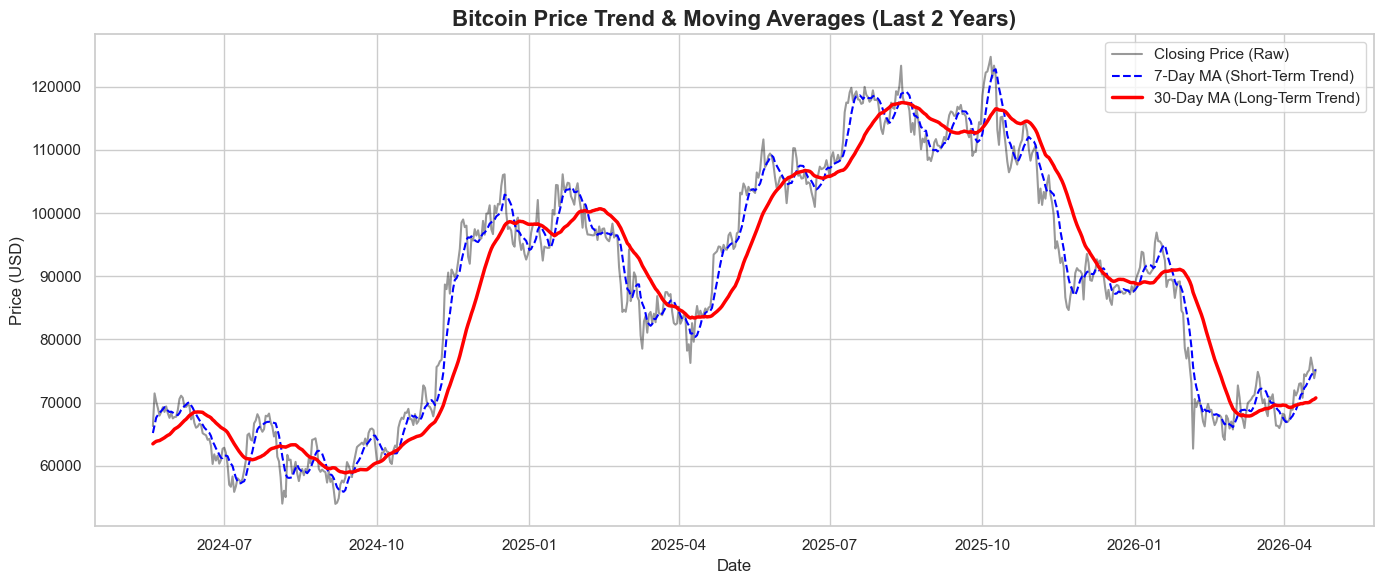

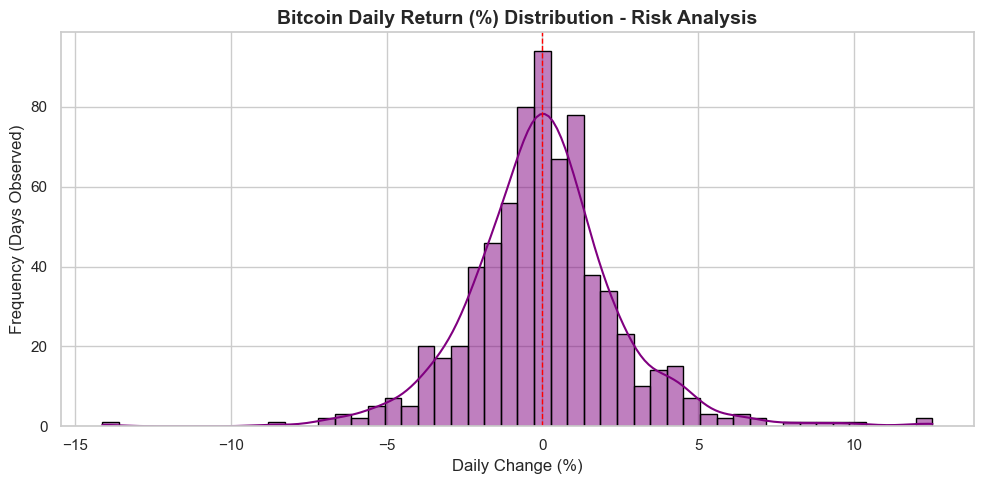

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 6))

plt.plot(df.index, df['Close'], label='Closing Price (Raw)', color='black', alpha=0.4, linewidth=1.5)
plt.plot(df.index, df['MA_7'], label='7-Day MA (Short-Term Trend)', color='blue', linestyle='--', linewidth=1.5)
plt.plot(df.index, df['MA_30'], label='30-Day MA (Long-Term Trend)', color='red', linewidth=2.5)

plt.title('Bitcoin Price Trend & Moving Averages (Last 2 Years)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

plt.figure(figsize=(10, 5))

sns.histplot(df['Daily_Return_%'], bins=50, kde=True, color='purple', edgecolor='black')

plt.title('Bitcoin Daily Return (%) Distribution - Risk Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Daily Change (%)', fontsize=12)
plt.ylabel('Frequency (Days Observed)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

Fetching multi-asset market data...


[*********************100%***********************]  3 of 3 completed

Multi-asset data fetched successfully!


Ticker,BTC-USD,ETH-USD,SOL-USD
Date,,,
2025-04-20,85174.304688,1587.514282,137.774597
2025-04-21,87518.906250,1579.734497,136.704391
2025-04-22,93441.890625,1757.331665,148.739410
2025-04-23,93699.109375,1796.104248,151.152725
2025-04-24,93943.796875,1769.831665,152.303635


Data normalized and correlation matrix calculated!


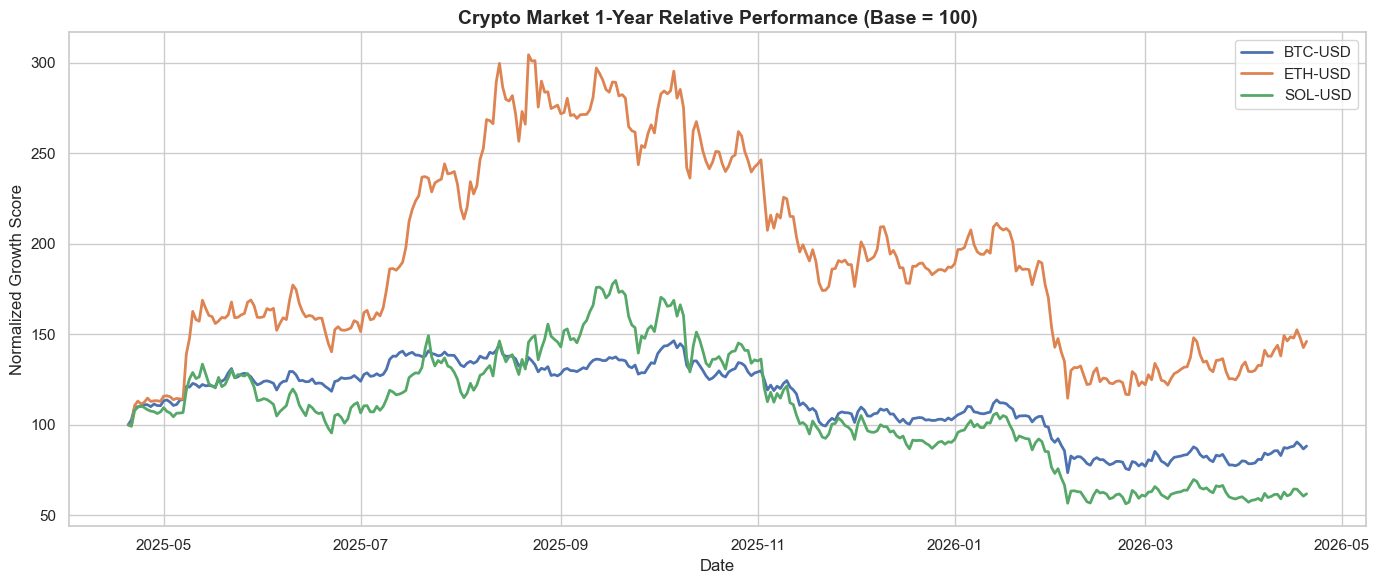

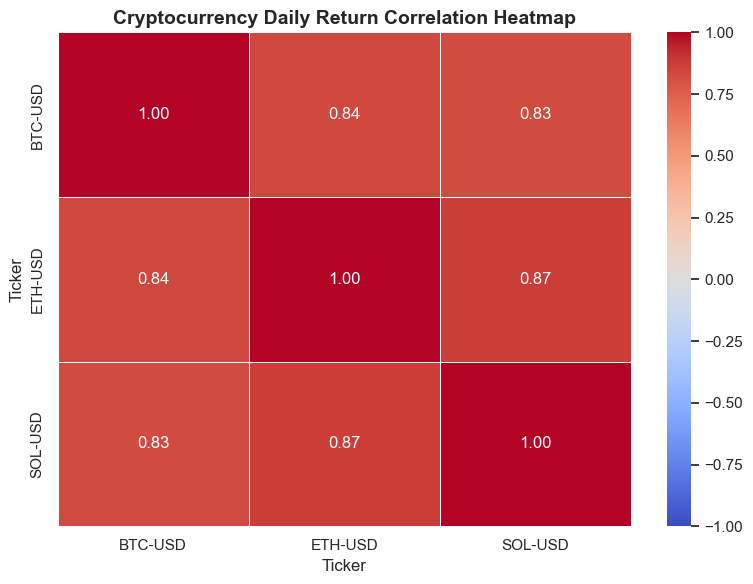

In [9]:
tickers = ['BTC-USD', 'ETH-USD', 'SOL-USD']

print("Fetching multi-asset market data...")
multi_data = yf.download(tickers, period='1y', interval='1d')['Close']

print("Multi-asset data fetched successfully!")
display(multi_data.head())

multi_data.dropna(inplace=True)

normalized_data = (multi_data / multi_data.iloc[0]) * 100

daily_returns_multi = multi_data.pct_change().dropna()
correlation_matrix = daily_returns_multi.corr()

print("Data normalized and correlation matrix calculated!")

plt.figure(figsize=(14, 6))
for col in normalized_data.columns:
    plt.plot(normalized_data.index, normalized_data[col], label=col, linewidth=2)

plt.title('Crypto Market 1-Year Relative Performance (Base = 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Growth Score', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, fmt=".2f")

plt.title('Cryptocurrency Daily Return Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()